<a href="https://colab.research.google.com/github/gogulasaimounika/Predictive-Analytics-lab/blob/student_admission_record_dirty/student_admission_record_dirty.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Accuracy: 0.36666666666666664

Confusion Matrix:
 [[ 6 13]
 [ 6  5]]

Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.32      0.39        19
           1       0.28      0.45      0.34        11

    accuracy                           0.37        30
   macro avg       0.39      0.39      0.37        30
weighted avg       0.42      0.37      0.37        30



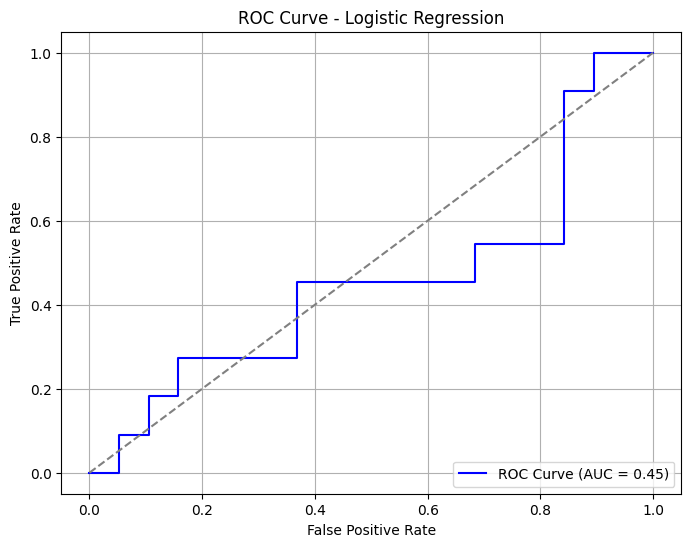


Feature Importance (coefficients):
City_Lahore               0.331596
High School Percentage    0.249115
City_Rawalpindi           0.219277
Age                       0.091878
Admission Test Score      0.063028
City_Multan              -0.019275
City_Peshawar            -0.021652
City_Quetta              -0.061267
Gender_Male              -0.075682
City_Karachi             -0.263622
dtype: float64


['scaler.pkl']

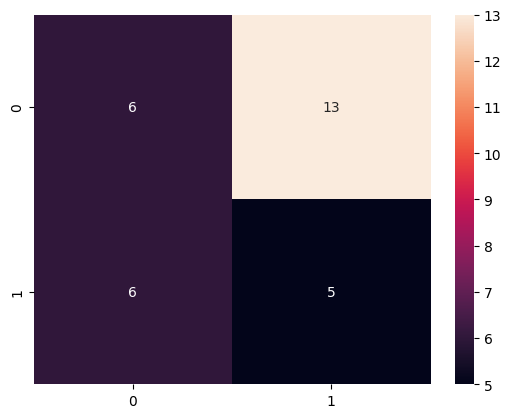

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)
from sklearn.preprocessing import StandardScaler
import joblib
import seaborn as sns
df = pd.read_csv("student_admission_record_dirty.csv")
df = df.dropna(subset=['Admission Status'])
df['Admission Status'] = df['Admission Status'].map({'Accepted': 1, 'Rejected': 0})
df['High School Percentage'] = df['High School Percentage'].fillna(df['High School Percentage'].median())
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Admission Test Score'] = df['Admission Test Score'].fillna(df['Admission Test Score'].median())
df_encoded = pd.get_dummies(df[['Gender', 'City']], drop_first=True)
X = pd.concat([
    df[['Age', 'Admission Test Score', 'High School Percentage']],
    df_encoded
], axis=1)
y = df['Admission Status']
X = X.dropna()
y = y.loc[X.index]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ROC Curve
y_proba = model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})", color='blue')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d")
# Feature Importance
feature_names = X.columns
coefficients = model.coef_[0]
feature_importance = pd.Series(coefficients, index=feature_names).sort_values(ascending=False)

print("\nFeature Importance (coefficients):")
print(feature_importance)

# Save model and scaler
joblib.dump(model, "logistic_regression_model.pkl")
joblib.dump(scaler, "scaler.pkl")
